# Weather Data: Clean, Combine & Vegetation-Filter Pipeline

**Purpose:** Process raw weather NetCDF files from two time periods, combine them
into a unified dataset, then spatially filter to only grid cells with combustible
vegetation (excluding Water, Urban, and Agriculture).

**Pipeline Overview:**

| Phase | Steps |
|-------|-------|
| **A. Convert Extended Data** | Read extended-period `.nc` files (1994–2000), validate compatibility, convert to `.parquet` |
| **B. Combine Time Periods** | Union extended (1994–2000) with main (2001–2023) weather data, harmonize column names, track missing rates |
| **C. Missing Rate QA** | Investigate anomalies in `max_air_temperature` (zeros) and `precipitation_amount` (zeros) |
| **D. Vegetation Filter** | Load vegetation grid, exclude Water/Urban/Agriculture, inner-join with weather data |

**Inputs:**

| Data | Path |
|------|------|
| Extended weather `.nc` (1994–2000) | `E:/zcao/CA_Wildfire/Extended_Data/Weather_Data/` |
| Main weather `.nc` (2001–2023) | `E:/zcao/CA_Wildfire/Weather_Data/` |
| Vegetation grid (from Veg pipeline) | `<clean_dir>/lon_lat_pair_weather_match_veg_v2.parquet` |

**Outputs:**

| Data | Path |
|------|------|
| Extended weather `.parquet` | `<clean_dir>/Weather_Data/Extended_Weather_Data/` |
| Combined weather `.parquet` | `<clean_dir>/Weather_Data/Combined_Weather_Data/` |
| Missing rate summary | `<summary_dir>/Missing_Rate/raw_weather_data.csv` |
| Final veg-filtered weather | `<clean_dir>/Weather_Data/Combined_Weather_Data_w_Veg_Filter/` |

## 0. Configuration

Centralized path configuration — **edit this cell only** to adapt to your local setup.

In [2]:
import os

# ====================== EDIT THESE PATHS ======================
PROJECT_ROOT = r"E:\zcao\CA_Wildfire"

# Input paths
EXTENDED_WEATHER_NC_DIR = os.path.join(PROJECT_ROOT, "Extended_Data", "Weather_Data")
MAIN_WEATHER_NC_DIR    = os.path.join(PROJECT_ROOT, "Weather_Data")

# Clean / output root
CLEAN_DIR   = os.path.join(PROJECT_ROOT, "Clean_Data")
SUMMARY_DIR = os.path.join(PROJECT_ROOT, "Summary_Data")
LOG_DIR     = os.path.join(PROJECT_ROOT, "Logs", "Clean_Extended_Data")

# Derived paths (auto-created)
EXTENDED_PARQUET_DIR  = os.path.join(CLEAN_DIR, "Weather_Data", "Extended_Weather_Data")
MAIN_PARQUET_DIR      = os.path.join(CLEAN_DIR, "Weather_Data")
COMBINED_DIR          = os.path.join(CLEAN_DIR, "Weather_Data", "Combined_Weather_Data")
COMBINED_VEG_DIR      = os.path.join(CLEAN_DIR, "Weather_Data", "Combined_Weather_Data_w_Veg_Filter")
MISSING_RATE_DIR      = os.path.join(SUMMARY_DIR, "Missing_Rate")
VEG_V2_PATH           = os.path.join(CLEAN_DIR, "Veg_Data", "lon_lat_pair_weather_match_veg_v2.parquet")

# Files to exclude from extended data (known problematic / different structure)
EXCLUDE_FILES = ["vapor_pressure_deficit", "pdsi", "spei"]
# ==============================================================

for d in [EXTENDED_PARQUET_DIR, COMBINED_DIR, COMBINED_VEG_DIR, MISSING_RATE_DIR, LOG_DIR]:
    os.makedirs(d, exist_ok=True)

print("Input paths:")
for label, path in [("Extended .nc dir", EXTENDED_WEATHER_NC_DIR),
                     ("Main .nc dir", MAIN_WEATHER_NC_DIR),
                     ("Veg v2 parquet", VEG_V2_PATH)]:
    exists = os.path.exists(path)
    status = "\u2713" if exists else "\u2717 NOT FOUND"
    print(f"  {status}  {label}: {path}")
print(f"\nOutput root: {CLEAN_DIR}")

Input paths:
  ✓  Extended .nc dir: E:\zcao\CA_Wildfire\Extended_Data\Weather_Data
  ✓  Main .nc dir: E:\zcao\CA_Wildfire\Weather_Data
  ✓  Veg v2 parquet: E:\zcao\CA_Wildfire\Clean_Data\Veg_Data\lon_lat_pair_weather_match_veg_v2.parquet

Output root: E:\zcao\CA_Wildfire\Clean_Data


## 1. Environment Setup

In [3]:
import sys
import gc
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import xarray as xr
import geopandas as gpd
import pyproj
import matplotlib.pyplot as plt
from datetime import datetime
from tqdm import tqdm

pd.set_option("display.max_colwidth", None)

print(f"Python     : {sys.version.split(chr(124))[0].strip()}")
print(f"pandas     : {pd.__version__}")
print(f"xarray     : {xr.__version__}")
print(f"numpy      : {np.__version__}")

Python     : 3.9.13 (main, Aug 25 2022, 23:51:50) [MSC v.1916 64 bit (AMD64)]
pandas     : 2.2.2
xarray     : 2024.7.0
numpy      : 1.24.4


---

# Phase A: Convert Extended Weather NetCDF to Parquet

Read the extended-period (1994–2000) `.nc` files, validate that they share
the same spatial grid, and convert each to `.parquet`.

## 2. Inspect Extended Weather Files

In [4]:
all_ext_files = sorted([f for f in os.listdir(EXTENDED_WEATHER_NC_DIR) if f.endswith(".nc")])
print(f"Total .nc files found: {len(all_ext_files)}")

# Exclude known problematic files
ext_files = [f for f in all_ext_files
             if not any(excl in f for excl in EXCLUDE_FILES)]

excluded = set(all_ext_files) - set(ext_files)
if excluded:
    print(f"Excluded: {sorted(excluded)}")
print(f"Files to process: {len(ext_files)}")

for f in ext_files:
    print(f"  {f}")

Total .nc files found: 14
Excluded: ['pdsi.CA.nc', 'spei.CA.nc', 'vapor_pressure_deficit.1994.2000.CA.nc']
Files to process: 11
  dead_fuel_moisture_1000h.1994.2000.CA.nc
  dead_fuel_moisture_100h.1994.2000.CA.nc
  max_air_temperature.1994.2000.CA.nc
  max_relative_humidity.1994.2000.CA.nc
  min_air_temperature.1994.2000.CA.nc
  min_relative_humidity.1994.2000.CA.nc
  precipitation_amount.1994.2000.CA.nc
  specific_humidity.1994.2000.CA.nc
  surface_downwelling_shortwave_flux.1994.2000.CA.nc
  wind_from_direction.1994.2000.CA.nc
  wind_speed.1994.2000.CA.nc


In [5]:
# Inspect each file's dimensions and date range
for file in ext_files:
    ds = xr.open_dataset(os.path.join(EXTENDED_WEATHER_NC_DIR, file))
    day_range = ""
    if "day" in ds.coords:
        day_range = f", days: {str(ds.coords['day'].min().values)[:10]} to {str(ds.coords['day'].max().values)[:10]}"
    print(f"  {file:55s} dims={dict(ds.dims)}{day_range}")
    ds.close()

  dead_fuel_moisture_1000h.1994.2000.CA.nc                dims={'lon': 258, 'lat': 238, 'day': 2557, 'crs': 1}, days: 1994-01-01 to 2000-12-31
  dead_fuel_moisture_100h.1994.2000.CA.nc                 dims={'lon': 258, 'lat': 238, 'day': 2557, 'crs': 1}, days: 1994-01-01 to 2000-12-31
  max_air_temperature.1994.2000.CA.nc                     dims={'lon': 258, 'lat': 238, 'day': 2557, 'crs': 1}, days: 1994-01-01 to 2000-12-31
  max_relative_humidity.1994.2000.CA.nc                   dims={'lon': 258, 'lat': 238, 'day': 2557, 'crs': 1}, days: 1994-01-01 to 2000-12-31
  min_air_temperature.1994.2000.CA.nc                     dims={'lon': 258, 'lat': 238, 'day': 2557, 'crs': 1}, days: 1994-01-01 to 2000-12-31
  min_relative_humidity.1994.2000.CA.nc                   dims={'lon': 258, 'lat': 238, 'day': 2557, 'crs': 1}, days: 1994-01-01 to 2000-12-31
  precipitation_amount.1994.2000.CA.nc                    dims={'lon': 258, 'lat': 238, 'day': 2557, 'crs': 1}, days: 1994-01-01 to 2000-12-31

### 2a. Check Grid Compatibility

Verify all files share the same spatial dimensions and coordinate arrays.
Files that don't match the reference are flagged.

In [6]:
def check_compatibility(ds1, ds2):
    """Check if two datasets share the same dims and coordinate values."""
    if ds1.dims != ds2.dims:
        return False
    return all(ds1.coords[dim].equals(ds2.coords[dim]) for dim in ds1.dims)

ref_ds = xr.open_dataset(os.path.join(EXTENDED_WEATHER_NC_DIR, ext_files[0]))
compatible_files = []
incompatible_files = []

for file in ext_files:
    ds = xr.open_dataset(os.path.join(EXTENDED_WEATHER_NC_DIR, file))
    if check_compatibility(ref_ds, ds):
        compatible_files.append(file)
    else:
        incompatible_files.append(file)
        print(f"  INCOMPATIBLE: {file}")
    ds.close()
ref_ds.close()

print(f"\nCompatible: {len(compatible_files)} / {len(ext_files)}")
if incompatible_files:
    print(f"Incompatible: {incompatible_files}")


Compatible: 11 / 11


### 2b. Convert Compatible Files to Parquet

In [7]:
for file in tqdm(compatible_files, desc="Converting .nc -> .parquet"):
    ds = xr.open_dataset(os.path.join(EXTENDED_WEATHER_NC_DIR, file))
    df = ds.to_dataframe().reset_index()

    # Drop constant 'crs' column if present
    if "crs" in df.columns and df["crs"].nunique() <= 1:
        df = df.drop(columns=["crs"])

    out_name = file.split(".")[0] + ".parquet"
    df.to_parquet(os.path.join(EXTENDED_PARQUET_DIR, out_name), index=False)

    ds.close()
    del ds, df
    gc.collect()

print(f"\nSaved {len(compatible_files)} parquet files to: {EXTENDED_PARQUET_DIR}")

Converting .nc -> .parquet: 100%|██████████| 11/11 [06:51<00:00, 37.43s/it]


Saved 11 parquet files to: E:\zcao\CA_Wildfire\Clean_Data\Weather_Data\Extended_Weather_Data


### 2c. Convert Main Weather `.nc` to Parquet (if needed)

The main weather data (2001–2023) may also need conversion from `.nc` to `.parquet`.
This cell checks whether parquet files already exist; if not, it converts them.

In [8]:
main_nc_files = sorted([f for f in os.listdir(MAIN_WEATHER_NC_DIR) if f.endswith(".nc")])
existing_parquets = set(os.listdir(MAIN_PARQUET_DIR)) if os.path.isdir(MAIN_PARQUET_DIR) else set()
os.makedirs(MAIN_PARQUET_DIR, exist_ok=True)

converted = 0
for file in tqdm(main_nc_files, desc="Main .nc -> .parquet (if needed)"):
    out_name = file.split(".")[0] + ".parquet"
    if out_name in existing_parquets:
        continue  # already converted

    ds = xr.open_dataset(os.path.join(MAIN_WEATHER_NC_DIR, file))
    df = ds.to_dataframe().reset_index()

    if "crs" in df.columns and df["crs"].nunique() <= 1:
        df = df.drop(columns=["crs"])

    # Add year column from 'day' if present
    if "day" in df.columns:
        df["year"] = df["day"].dt.year

    df.to_parquet(os.path.join(MAIN_PARQUET_DIR, out_name), index=False)
    converted += 1

    ds.close()
    del ds, df
    gc.collect()

if converted > 0:
    print(f"Converted {converted} main weather files to: {MAIN_PARQUET_DIR}")
else:
    print(f"All {len(main_nc_files)} main weather parquets already exist — skipping conversion")

Main .nc -> .parquet (if needed): 100%|██████████| 14/14 [36:52<00:00, 158.04s/it]

Converted 14 main weather files to: E:\zcao\CA_Wildfire\Clean_Data\Weather_Data


---

# Phase B: Combine Extended + Main Weather Data

For each weather variable, union the extended period (1994–2000) with the main
period (2001–2023). Handle naming mismatches between the two sources:

- `dead_fuel_moisture_100h` (extended) vs `dead_fuel_moisture_100hr` (main)
- `dead_fuel_moisture_1000h` (extended) vs `dead_fuel_moisture_1000hr` (main)
- `air_temperature` / `relative_humidity` columns need `max_` or `min_` prefix based on filename

## 3. Combine Time Periods & Track Missing Rates

In [9]:
# Build filename mapping: extended -> main (handle naming differences)
NAME_FIXES = {
    "dead_fuel_moisture_100h.parquet":  "dead_fuel_moisture_100hr.parquet",
    "dead_fuel_moisture_1000h.parquet": "dead_fuel_moisture_1000hr.parquet",
}

ext_parquet_files = sorted([f for f in os.listdir(EXTENDED_PARQUET_DIR) if f.endswith(".parquet")])
missing_rate_dict = {}

for file in tqdm(ext_parquet_files, desc="Combining time periods"):
    # --- Load extended data ---
    dat_ext = pd.read_parquet(os.path.join(EXTENDED_PARQUET_DIR, file))

    # --- Load main data (with name fix if needed) ---
    main_file = NAME_FIXES.get(file, file)
    main_path = os.path.join(MAIN_PARQUET_DIR, main_file)
    if not os.path.exists(main_path):
        print(f"  SKIP {file}: no matching main file ({main_file})")
        del dat_ext
        gc.collect()
        continue
    dat_main = pd.read_parquet(main_path)

    # Add year column from main data's 'day' column
    dat_main["year"] = dat_main["day"].dt.year

    # Align extended columns to match main
    dat_ext = dat_ext[dat_main.columns]

    # Union
    combined = pd.concat([dat_ext, dat_main], ignore_index=True)

    # Rename ambiguous columns based on filename
    if "air_temperature" in combined.columns:
        prefix = "max" if "max" in file else "min"
        combined.rename(columns={"air_temperature": f"{prefix}_air_temperature"}, inplace=True)
    if "relative_humidity" in combined.columns:
        prefix = "max" if "max" in file else "min"
        combined.rename(columns={"relative_humidity": f"{prefix}_relative_humidity"}, inplace=True)

    # Track missing rate per year for the weather variable (4th column)
    weather_var = combined.columns[3]
    yearly_missing = combined.groupby("year")[weather_var].apply(lambda x: x.isnull().mean())
    for year, rate in yearly_missing.items():
        if year not in missing_rate_dict:
            missing_rate_dict[year] = {}
        missing_rate_dict[year][weather_var] = rate

    # Save combined
    combined.to_parquet(os.path.join(COMBINED_DIR, file), index=False)

    del dat_ext, dat_main, combined
    gc.collect()

print(f"\nCombined files saved to: {COMBINED_DIR}")

Combining time periods: 100%|██████████| 11/11 [27:29<00:00, 149.93s/it]


Combined files saved to: E:\zcao\CA_Wildfire\Clean_Data\Weather_Data\Combined_Weather_Data


## 4. Missing Rate Summary

Review per-year missing rates across all weather variables.
Large jumps between time periods flag data-quality issues.

In [10]:
missing_rate_df = (
    pd.DataFrame.from_dict(missing_rate_dict, orient="index")
    .sort_index()
)
missing_rate_df.index.name = "year"

# Save
missing_csv = os.path.join(MISSING_RATE_DIR, "raw_weather_data.csv")
missing_rate_df.to_csv(missing_csv)
print(f"Missing rate summary saved to: {missing_csv}")
print()
missing_rate_df

Missing rate summary saved to: E:\zcao\CA_Wildfire\Summary_Data\Missing_Rate\raw_weather_data.csv



,dead_fuel_moisture_1000hr,dead_fuel_moisture_100hr,max_air_temperature,max_relative_humidity,min_air_temperature,min_relative_humidity,precipitation_amount,specific_humidity,surface_downwelling_shortwave_flux_in_air,wind_from_direction,wind_speed
year,,,,,,,,,,,
1994,0.599554,0.599554,0.599554,0.599554,0.599554,0.599554,0.599554,0.599554,0.599554,0.599554,0.599554
1995,0.599554,0.599554,0.599554,0.599554,0.599554,0.599554,0.599554,0.599554,0.599554,0.599554,0.599554
1996,0.599554,0.599554,0.599554,0.599554,0.599554,0.599554,0.599554,0.599554,0.599554,0.599554,0.599554
1997,0.599554,0.599554,0.599554,0.599554,0.599554,0.599554,0.599554,0.599554,0.599554,0.599554,0.599554
1998,0.599554,0.599554,0.599554,0.599554,0.599554,0.599554,0.599554,0.599554,0.599554,0.599554,0.599554
1999,0.599554,0.599554,0.599554,0.599554,0.599554,0.599554,0.599554,0.599554,0.599554,0.599554,0.599554
2000,0.599554,0.599554,0.599554,0.599554,0.599554,0.599554,0.599554,0.599554,0.599554,0.599554,0.599554
2001,0.602928,0.602928,0.004376,0.602928,0.004376,0.602928,0.916766,0.602928,0.602928,0.603448,0.602928
2002,0.602928,0.602928,0.004376,0.602928,0.004376,0.602954,0.942734,0.602928,0.602928,0.603475,0.602928


---

# Phase C: Missing Rate Investigation

Known anomalies between the two time periods:

- **`max_air_temperature`:** Post-2000 data includes `0` values that are actually missing.
  Replacing `0 -> NaN` normalizes the missing rate across years.
- **`precipitation_amount`:** Extended data includes `0` (no-rain days),
  but main data excludes them. After removing zeros from extended data,
  missing rates align.

### 4a. Max Air Temperature — Zero Investigation

In [11]:
max_temp = pd.read_parquet(os.path.join(COMBINED_DIR, "max_air_temperature.parquet"))

# Replace zeros with NaN (they represent missing data, not true 0 K/C)
max_temp["max_air_temperature"] = max_temp["max_air_temperature"].replace(0, np.nan)

print("Missing rate by year (after 0 -> NaN):")
print(max_temp.groupby("year")["max_air_temperature"].apply(lambda x: x.isnull().mean()).to_string())

Missing rate by year (after 0 -> NaN):
year
1994    0.599554
1995    0.599554
1996    0.599554
1997    0.599554
1998    0.599554
1999    0.599554
2000    0.599554
2001    0.602928
2002    0.602928
2003    0.602928
2004    0.602928
2005    0.602928
2006    0.602928
2007    0.602928
2008    0.602928
2009    0.602928
2010    0.602928
2011    0.602928
2012    0.602928
2013    0.602928
2014    0.602928
2015    0.602928
2016    0.602928
2017    0.602928
2018    0.602928
2019    0.602928
2020    0.602928
2021    0.602928
2022    0.602928
2023    0.602928


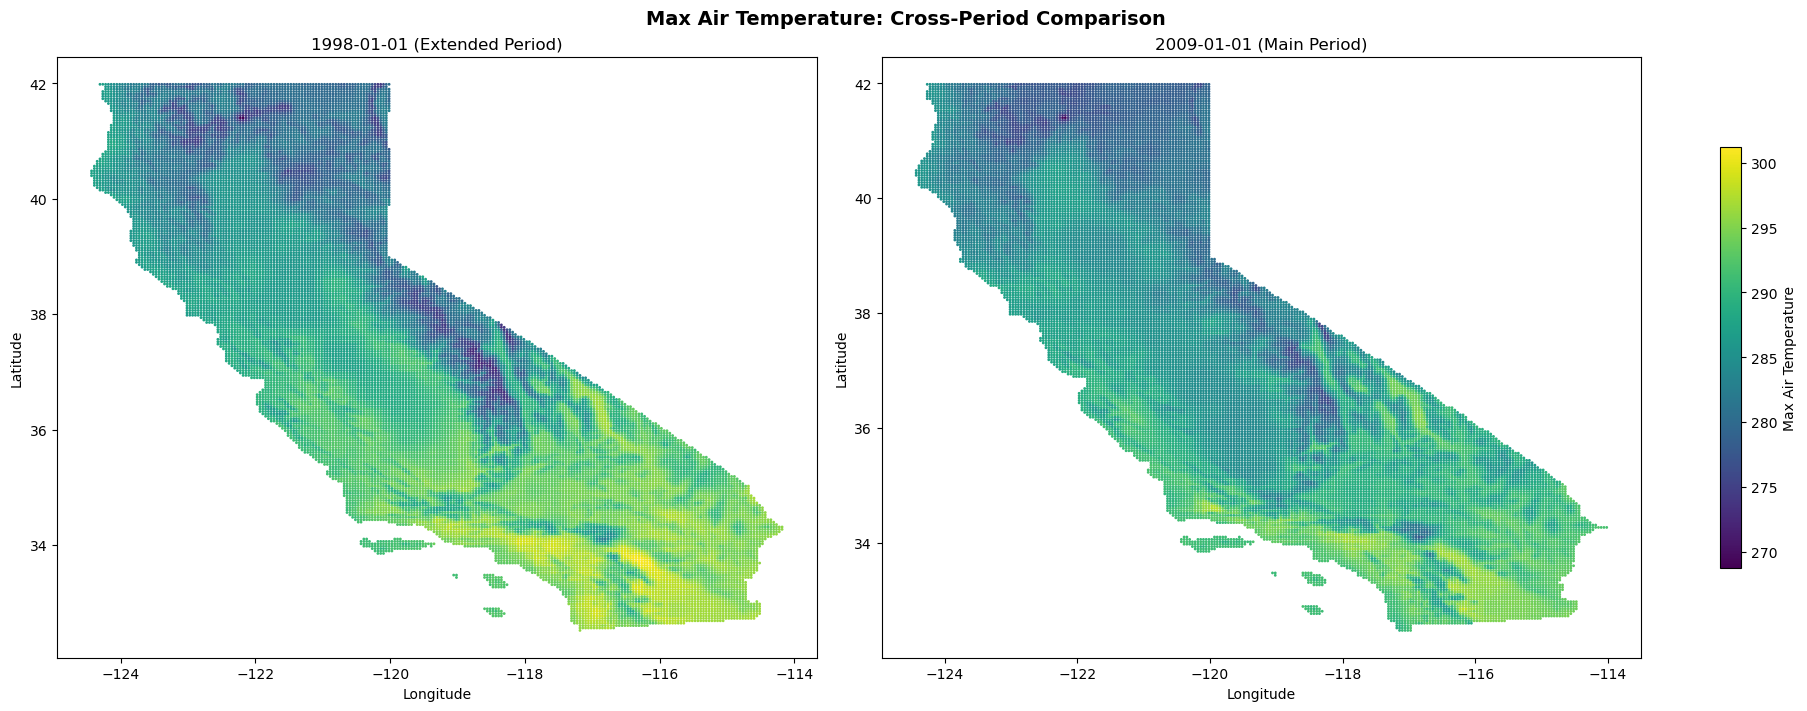

20

In [12]:
# Visual comparison: one date from each period
dat_early = max_temp[max_temp["day"] == "1998-01-01"]
dat_late  = max_temp[max_temp["day"] == "2009-01-01"]

vmin = min(dat_early["max_air_temperature"].min(), dat_late["max_air_temperature"].min())
vmax = max(dat_early["max_air_temperature"].max(), dat_late["max_air_temperature"].max())

fig, axes = plt.subplots(1, 2, figsize=(18, 7), constrained_layout=True)

axes[0].scatter(dat_early["lon"], dat_early["lat"],
                c=dat_early["max_air_temperature"], cmap="viridis", s=1, vmin=vmin, vmax=vmax)
axes[0].set_title("1998-01-01 (Extended Period)")
axes[0].set_xlabel("Longitude")
axes[0].set_ylabel("Latitude")

sc = axes[1].scatter(dat_late["lon"], dat_late["lat"],
                     c=dat_late["max_air_temperature"], cmap="viridis", s=1, vmin=vmin, vmax=vmax)
axes[1].set_title("2009-01-01 (Main Period)")
axes[1].set_xlabel("Longitude")
axes[1].set_ylabel("Latitude")
fig.colorbar(sc, ax=axes, label="Max Air Temperature", shrink=0.7)

plt.suptitle("Max Air Temperature: Cross-Period Comparison", fontsize=14, fontweight="bold")
plt.show()
plt.close()

del max_temp, dat_early, dat_late
gc.collect()

### 4b. Precipitation — Zero Investigation

In [13]:
rain = pd.read_parquet(os.path.join(COMBINED_DIR, "precipitation_amount.parquet"))

# Check missing rate after removing zeros (aligns the two periods)
rain_nonzero = rain[rain["precipitation_amount"] != 0]
print("Missing rate by year (zeros excluded):")
print(rain_nonzero.groupby("year")["precipitation_amount"].apply(lambda x: x.isnull().mean()).to_string())

Missing rate by year (zeros excluded):
year
1994    0.866132
1995    0.846421
1996    0.848896
1997    0.870008
1998    0.807919
1999    0.874323
2000    0.868701
2001    0.916766
2002    0.942734
2003    0.916357
2004    0.929357
2005    0.908471
2006    0.912473
2007    0.937350
2008    0.937784
2009    0.934598
2010    0.919427
2011    0.930437
2012    0.933082
2013    0.957305
2014    0.945744
2015    0.941770
2016    0.924137
2017    0.925220
2018    0.938591
2019    0.912163
2020    0.946733
2021    0.934854
2022    0.947258
2023    0.917471


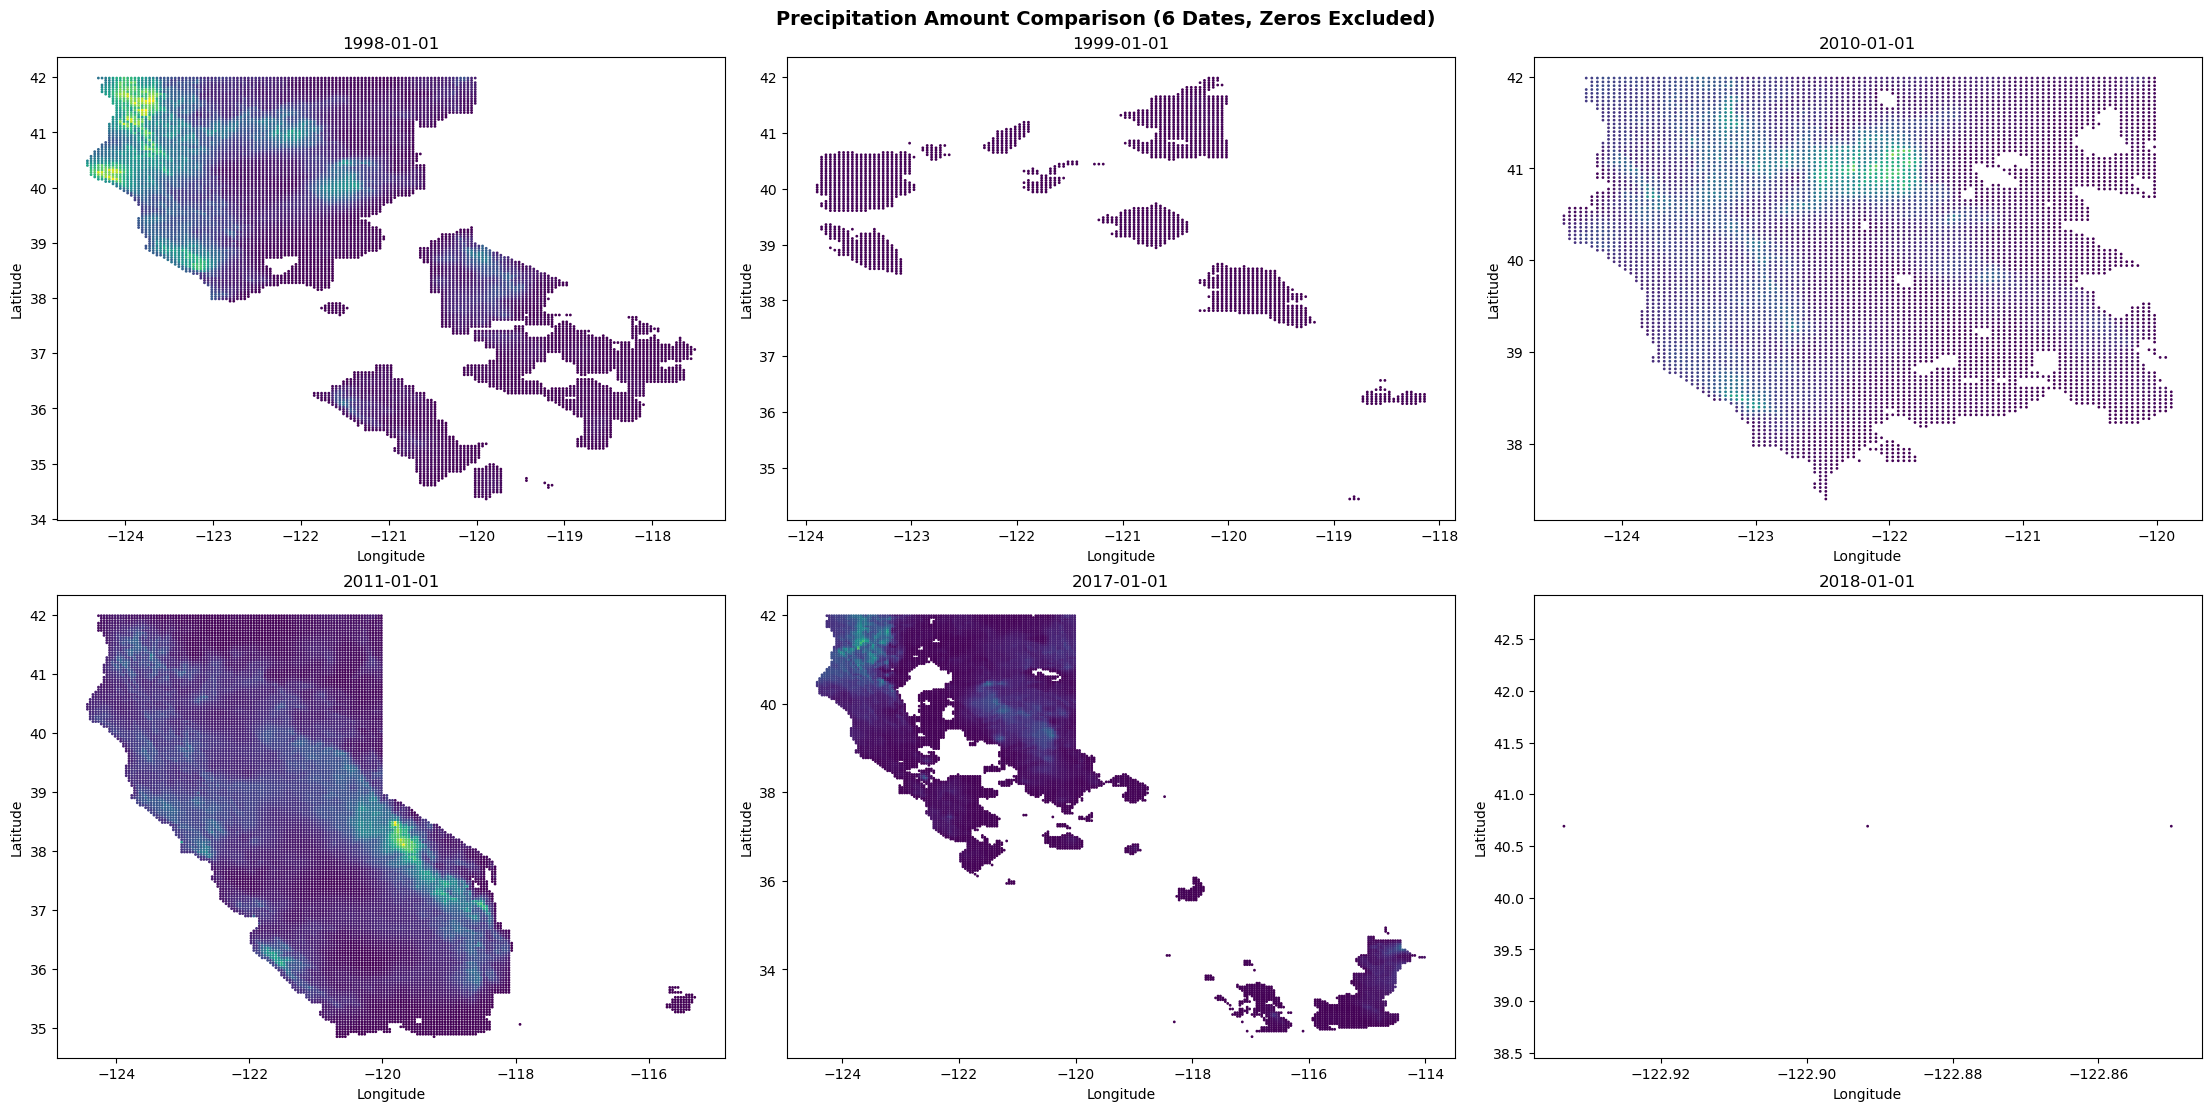

15

In [14]:
# Visual comparison across 6 dates spanning both periods
dates = ["1998-01-01", "1999-01-01", "2010-01-01", "2011-01-01", "2017-01-01", "2018-01-01"]
data_list = [rain_nonzero[rain_nonzero["day"] == d] for d in dates]

vmin = min(df["precipitation_amount"].min() for df in data_list if len(df) > 0)
vmax = max(df["precipitation_amount"].max() for df in data_list if len(df) > 0)

fig, axes = plt.subplots(2, 3, figsize=(22, 11), constrained_layout=True)
axes = axes.flatten()

for i, (ax, date) in enumerate(zip(axes, dates)):
    if len(data_list[i]) > 0:
        ax.scatter(data_list[i]["lon"], data_list[i]["lat"],
                   c=data_list[i]["precipitation_amount"], cmap="viridis",
                   s=1, vmin=vmin, vmax=vmax)
    ax.set_title(date)
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")

plt.suptitle("Precipitation Amount Comparison (6 Dates, Zeros Excluded)",
             fontsize=14, fontweight="bold")
plt.show()
plt.close()

del rain, rain_nonzero
gc.collect()

---

# Phase D: Vegetation Filter

Spatially filter the combined weather data to only include grid cells
with combustible vegetation — excluding Water, Urban, and Agriculture types.

## 5. Load & Filter Vegetation Grid

In [15]:
# Clean up memory before this heavy phase
gc.collect()

veg_data = pd.read_parquet(VEG_V2_PATH)
print(f"Vegetation grid: {veg_data.shape[0]:,} rows")
print(f"Unique lon/lat pairs: {veg_data[['lon','lat']].drop_duplicates().shape[0]:,}")
print(f"Columns: {list(veg_data.columns)}")
veg_data.head()

Vegetation grid: 17,714 rows
Unique lon/lat pairs: 17,714
Columns: ['lon', 'lat', 'type', 'distance', 'veg_type_details', 'fire_attribute', 'veg']


,lon,lat,type,distance,veg_type_details,fire_attribute,veg
0,-122.766667,42.066667,10.0,1.800109,Native Conifer Alpine - low,low,Native Conifer Alpine
1,-122.725000,42.066667,10.0,1.800109,Native Conifer Alpine - low,low,Native Conifer Alpine
2,-122.683333,42.066667,11.0,1.800109,Native Conifer Forest - archetypical,archetypical,Native Conifer Forest
3,-122.641667,42.066667,12.0,1.800109,Native Conifer Forest - fire,fire,Native Conifer Forest
4,-122.891667,42.025000,17.0,1.800796,Native Desert - rarely,rarely,Native Desert


In [16]:
# Filter out non-combustible vegetation types
veg_all = veg_data.copy()
veg_filtered = veg_data[~veg_data["veg"].str.contains("Water|Urban|Agriculture")]

print(f"Before filter: {len(veg_all):,} grid cells")
print(f"After filter:  {len(veg_filtered):,} grid cells")
print(f"Removed:       {len(veg_all) - len(veg_filtered):,} (Water/Urban/Agriculture)")

Before filter: 17,714 grid cells
After filter:  14,394 grid cells
Removed:       3,320 (Water/Urban/Agriculture)


### Vegetation Filter QA: All vs. Filtered

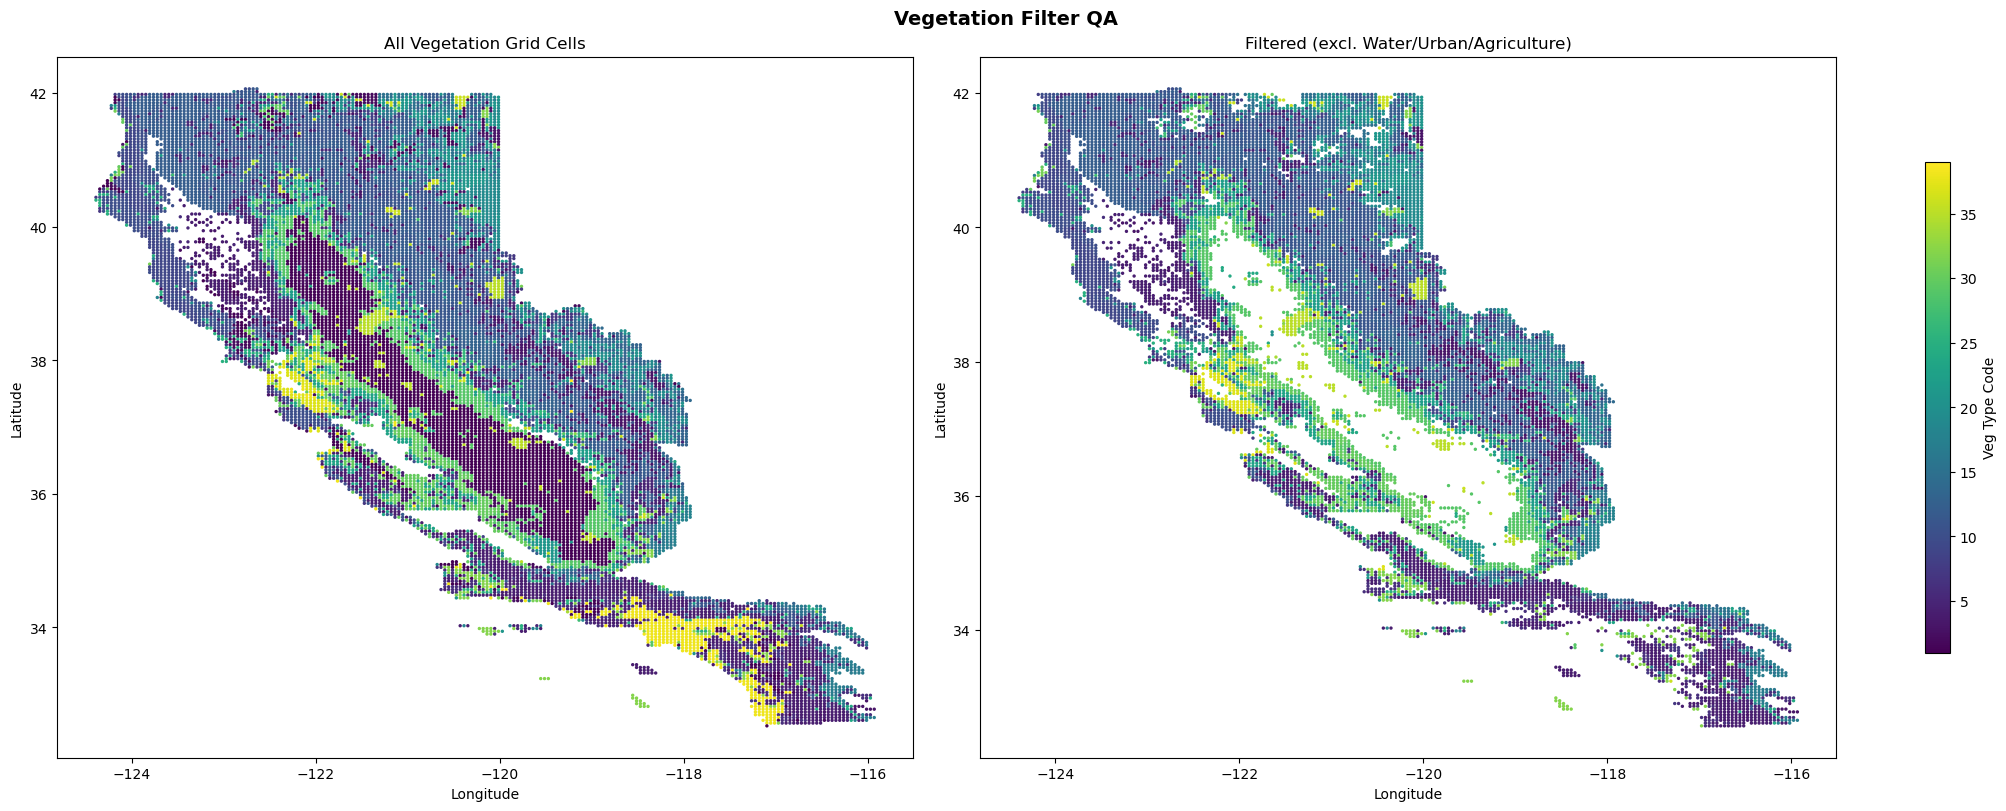

In [17]:
vmin = min(veg_all["type"].min(), veg_filtered["type"].min())
vmax = max(veg_all["type"].max(), veg_filtered["type"].max())

fig, axes = plt.subplots(1, 2, figsize=(20, 8), constrained_layout=True)

sc1 = axes[0].scatter(veg_all["lon"], veg_all["lat"],
                      c=veg_all["type"], cmap="viridis", s=2, vmin=vmin, vmax=vmax)
axes[0].set_title("All Vegetation Grid Cells")
axes[0].set_xlabel("Longitude")
axes[0].set_ylabel("Latitude")

sc2 = axes[1].scatter(veg_filtered["lon"], veg_filtered["lat"],
                      c=veg_filtered["type"], cmap="viridis", s=2, vmin=vmin, vmax=vmax)
axes[1].set_title("Filtered (excl. Water/Urban/Agriculture)")
axes[1].set_xlabel("Longitude")
axes[1].set_ylabel("Latitude")
fig.colorbar(sc2, ax=axes, label="Veg Type Code", shrink=0.7)

plt.suptitle("Vegetation Filter QA", fontsize=14, fontweight="bold")
plt.show()
plt.close()

## 6. Apply Vegetation Filter to Combined Weather Data

Inner-join each combined weather parquet file with the filtered vegetation grid.
This keeps only grid cells that have combustible vegetation.

In [18]:
combined_files = sorted([f for f in os.listdir(COMBINED_DIR) if f.endswith(".parquet")])

log_messages = []
log_messages.append("Task: Apply vegetation filter to combined weather data")
log_messages.append(f"Processing started: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
log_messages.append(f"Filter grid cells: {len(veg_filtered):,}")
log_messages.append("")

filter_keys = veg_filtered[["lon", "lat"]].drop_duplicates()

for file in tqdm(combined_files, desc="Applying veg filter"):
    dat = pd.read_parquet(os.path.join(COMBINED_DIR, file))
    n_before = len(dat)

    dat_filtered = dat.merge(filter_keys, on=["lon", "lat"], how="inner")
    n_after = len(dat_filtered)

    log_messages.append(f"{file}: {n_before:,} -> {n_after:,} rows ({n_after/n_before*100:.1f}% retained)")

    dat_filtered.to_parquet(os.path.join(COMBINED_VEG_DIR, file), index=False)

    del dat, dat_filtered
    gc.collect()

print(f"\nFiltered files saved to: {COMBINED_VEG_DIR}")

Applying veg filter: 100%|██████████| 11/11 [20:19<00:00, 110.89s/it]


Filtered files saved to: E:\zcao\CA_Wildfire\Clean_Data\Weather_Data\Combined_Weather_Data_w_Veg_Filter


## 7. Save Processing Log

In [19]:
log_messages.append("")
log_messages.append(f"Pipeline finished: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

log_path = os.path.join(LOG_DIR, "clean_weather_data_log.txt")
with open(log_path, "w") as f:
    f.write("\n".join(log_messages))

print(f"Log saved to: {log_path}")
print()
print("\n".join(log_messages))

Log saved to: E:\zcao\CA_Wildfire\Logs\Clean_Extended_Data\clean_weather_data_log.txt

Task: Apply vegetation filter to combined weather data
Processing started: 2026-03-17 11:18:38
Filter grid cells: 14,394

dead_fuel_moisture_1000h.parquet: 679,154,028 -> 157,622,658 rows (23.2% retained)
dead_fuel_moisture_100h.parquet: 679,154,028 -> 157,622,658 rows (23.2% retained)
max_air_temperature.parquet: 679,154,028 -> 157,622,658 rows (23.2% retained)
max_relative_humidity.parquet: 679,154,028 -> 157,622,658 rows (23.2% retained)
min_air_temperature.parquet: 679,154,028 -> 157,622,658 rows (23.2% retained)
min_relative_humidity.parquet: 679,154,028 -> 157,622,658 rows (23.2% retained)
precipitation_amount.parquet: 679,154,028 -> 157,622,658 rows (23.2% retained)
specific_humidity.parquet: 679,154,028 -> 157,622,658 rows (23.2% retained)
surface_downwelling_shortwave_flux.parquet: 679,154,028 -> 157,622,658 rows (23.2% retained)
wind_from_direction.parquet: 679,154,028 -> 157,622,658 rows (

## 8. Summary

| Phase | Step | Description |
|-------|------|-------------|
| A | Inspect & validate | Check extended `.nc` files for grid compatibility |
| A | Convert | Extended `.nc` -> `.parquet` (drop constant `crs` column) |
| B | Combine | Union extended (1994–2000) + main (2001–2023) per variable |
| B | Rename | Disambiguate `air_temperature` -> `max_`/`min_`, same for humidity |
| B | Missing rates | Track per-year missing rates for QA |
| C | Investigate | `max_air_temperature`: zeros = missing; `precipitation`: zeros = no-rain |
| D | Veg filter | Exclude Water/Urban/Agriculture grid cells |
| D | Save | Final filtered weather parquets ready for modeling |

**Next steps:** Merge the veg-filtered weather data with the fire ignition dataset
to build the feature matrix for ignition-risk modeling.